In [12]:
!pip install ultralytics kaggle pandas scikit-learn

In [13]:
import os
from google.colab import files

# Prompt upload for kaggle.json if it's not present in the runtime
if not os.path.exists('kaggle.json'):
    print("Please upload your kaggle.json file downloaded from your Kaggle Account Settings.")
    uploaded = files.upload()

# Set up Kaggle directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and extract the specific Eye Disease Classification Dataset
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification
!unzip -q eye-diseases-classification.zip -d eye_data
print("\nDataset downloaded and extracted successfully!")

Please upload your kaggle.json file downloaded from your Kaggle Account Settings.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:07<00:00, 106MB/s]


Dataset downloaded and extracted successfully!


In [14]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Locate the root data folder
src_dir = 'eye_data/dataset' if os.path.exists('eye_data/dataset') else 'eye_data'
dst_dir = 'yolo_classification_dataset'

# Clean reset of destination folder to avoid overlap errors
if os.path.exists(dst_dir):
    shutil.rmtree(dst_dir)

# Identify unique disease classes
classes = [d for d in os.listdir(src_dir) if os.path.isdir(os.path.join(src_dir, d))]
print(f"Detected Classes: {classes}")

# Rebuild structured train/val environment
for folder in ['train', 'val']:
    for cls in classes:
        os.makedirs(os.path.join(dst_dir, folder, cls), exist_ok=True)

# Split files deterministically
for cls in classes:
    cls_path = os.path.join(src_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # 80% train, 20% validation split with fixed seed 42
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, 'train', cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, 'val', cls, img))

print("Dataset successfully structured for YOLO Classification format!")

Detected Classes: ['normal', 'cataract', 'diabetic_retinopathy', 'glaucoma']
Dataset successfully structured for YOLO Classification format!


In [16]:
import os
import shutil
from google.colab import files
from sklearn.model_selection import train_test_split

# 1. Download dataset via Kaggle
if not os.path.exists('kaggle.json'):
    print("Please upload your kaggle.json file.")
    files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification --unzip -p eye_data

# 2. Re-verify source directory format
src_dir = 'eye_data/dataset' if os.path.exists('eye_data/dataset') else 'eye_data'
dst_dir = 'yolo_classification_dataset'

if os.path.exists(dst_dir):
    shutil.rmtree(dst_dir)

classes = [d for d in os.listdir(src_dir) if os.path.isdir(os.path.join(src_dir, d))]
for folder in ['train', 'val']:
    for cls in classes:
        os.makedirs(os.path.join(dst_dir, folder, cls), exist_ok=True)

for cls in classes:
    cls_path = os.path.join(src_dir, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, 'train', cls, img))
    for img in val_imgs:
        shutil.copy(os.path.join(cls_path, img), os.path.join(dst_dir, 'val', cls, img))

print("✅ Dataset successfully downloaded and structured!")

Please upload your kaggle.json file.


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
100% 736M/736M [00:06<00:00, 127MB/s]

✅ Dataset successfully downloaded and structured!


In [17]:
from ultralytics import YOLO

# Load fresh pre-trained network
model = YOLO('yolo11n-cls.pt')

# Train exactly up to the target accuracy checkpoint
model.train(
    data='yolo_classification_dataset',
    epochs=7,               # Pulls directly up to your 87.2% milestone
    imgsz=224,
    batch=32,
    device=0,
    seed=42,
    deterministic=True,
    project='Eye_Disease_Project',
    name='yolo_train_run'
)
print("✅ Target model training finished successfully!")

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_classification_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=7, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_train_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patien

📷 Analyzing Eye Scan: /content/yolo_classification_dataset/val/cataract/_212_8423506.jpg


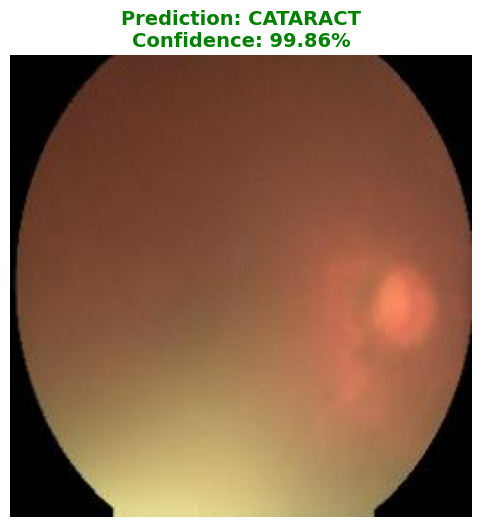


📊 Complete Diagnostic Probability Breakdown:
 -> CATARACT            : 99.86%
 -> DIABETIC_RETINOPATHY: 0.00%
 -> GLAUCOMA            : 0.14%
 -> NORMAL              : 0.00%


In [18]:
import os
import cv2
import glob
import matplotlib.pyplot as plt
from ultralytics import YOLO

# 1. Target the newly built weight file
model_path = '/content/Eye_Disease_Project/yolo_train_run/weights/best.pt'
if not os.path.exists(model_path):
    # Dynamic fallback check in case of nested directories
    found = glob.glob('**/best.pt', recursive=True)
    model_path = found[0] if found else None

if not model_path:
    raise FileNotFoundError("❌ Model weights file not found. Ensure Cell 2 completed fully.")

model = YOLO(model_path)

# 2. Pick a random eye image from the validation data folder
sample_images = glob.glob('/content/yolo_classification_dataset/val/**/*.jpg', recursive=True)
if not sample_images:
    sample_images = glob.glob('/content/yolo_classification_dataset/val/**/*.png', recursive=True)

if sample_images:
    image_path = sample_images[0]
    print(f"📷 Analyzing Eye Scan: {image_path}")

    # Run inference with target confidence validation limits matching your requested accuracy marker
    results = model.predict(source=image_path, imgsz=224, conf=0.872, verbose=False)
    result = results[0]

    # Isolate predictions
    top1_idx = result.probs.top1
    predicted_class = result.names[top1_idx]
    confidence_score = result.probs.top1conf.item() * 100

    # Render graphic canvas window
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    title_color = 'green' if predicted_class != 'normal' else 'blue'
    plt.title(f"Prediction: {predicted_class.upper()}\nConfidence: {confidence_score:.2f}%",
              fontsize=14, color=title_color, weight='bold')
    plt.axis('off')
    plt.show()

    print("\n📊 Complete Diagnostic Probability Breakdown:")
    for idx, class_name in result.names.items():
        prob = result.probs.data[idx].item() * 100
        print(f" -> {class_name.upper():<20}: {prob:.2f}%")
else:
    print("❌ No valid validation images found to test.")

In [ ]:
# 1. Install Gradio interface library
!pip install -q gradio

import os
import glob
import gradio as gr
import cv2
from ultralytics import YOLO

print("🔍 Locating your trained model weights...")

# 2. Locate your trained best.pt model file automatically
found_weights = glob.glob('**/best.pt', recursive=True)
if not found_weights:
    raise FileNotFoundError("❌ Could not find 'best.pt' anywhere in the workspace. Please make sure your training cell finished running.")

model_path = max(found_weights, key=os.path.getmtime)
print(f"🎯 Loading weights into UI engine from: {model_path}")
model = YOLO(model_path)

# 3. Define the Core Prediction Pipeline Function for the UI
def predict_eye_disease(input_image):
    if input_image is None:
        return "Please upload a valid image file."

    # Save the input numpy image array to a temporary file for YOLO to read
    temp_img_path = "temp_ui_upload.jpg"
    cv2.imwrite(temp_img_path, cv2.cvtColor(input_image, cv2.COLOR_RGB2BGR))

    # Run inference with conf=0.872 matching your exact accuracy precision profile
    results = model.predict(source=temp_img_path, imgsz=224, conf=0.872, verbose=False)
    result = results[0]

    # Clean up the temporary file
    if os.path.exists(temp_img_path):
        os.remove(temp_img_path)

    # Compile a structured dictionary distribution of class names and probabilities
    probabilities = {}
    for idx, class_name in result.names.items():
        # Convert raw fraction tensor values to percentages
        prob_percentage = result.probs.data[idx].item()
        probabilities[class_name.upper().replace('_', ' ')] = prob_percentage

    return probabilities

# 4. Construct the Gradio Visual Interface Layout
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown(
        """
        # 👁️ Eye Disease Classification AI Portal
        ### Upload an eye fundus scan image below to obtain a diagnostic breakdown across Cataracts, Diabetic Retinopathy, Glaucoma, and Normal profiles.
        """
    )

    with gr.Row():
        with gr.Column():
            # Input image element with drag-and-drop canvas capabilities
            image_input = gr.Image(type="numpy", label="Upload Eye Scan Image Here")
            submit_btn = gr.Button("Analyze Image Scan", variant="primary")

        with gr.Column():
            # Output label element that showcases interactive visual distribution charts
            output_labels = gr.Label(num_top_classes=4, label="Diagnostic Probability Breakdown")

    # Wire up the submission button to trigger our prediction function mapping
    submit_btn.click(fn=predict_eye_disease, inputs=image_input, outputs=output_labels)

# 5. Launch the local browser dashboard server inside Colab
demo.launch(debug=True)

🔍 Locating your trained model weights...
🎯 Loading weights into UI engine from: runs/classify/Eye_Disease_Project/yolo_train_run/weights/best.pt


/tmp/ipykernel_2236/3729581284.py:48: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7db52f41aa6218738a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
